# Test out source code

In [1]:
using Pkg 
Pkg.activate("../.")
Pkg.instantiate()
include("../src/model.jl")
include("../parameters/RA_long.jl")

  Activating project at `~/github/FisheriesInsuranceModel`


ComponentVector{Float64}(b0 = 1.0, g = 0.8976275964304349, m̄ = 0.11, m̲ = 0.8031471805599453, r0 = 0.02040344274221344, z = 0.75, b_target = 0.4, b_limit = 0.2, f_target = 0.08218551792854177, T = [0.975 0.5; 0.025 0.5], σ_R = 0.75, μZ = 0.0, μ_P = 33.435598905765794, μ_Ce = 0.0, s̄ = -2.0, k = 0.0, y0 = 0.01, cf = 1.0e-6, cv = 0.0, κ_bankrupt = 0.01, γ = 1.001)

## Set up random variables

In [2]:
X, Xmc = init_ranom_variables(p;Nquad = 5)

(ValueFunctionIterations.RandomVariableFunction(var"#Xf#2"{RandomVariable}(RandomVariable([0.0 0.0 … 0.0 0.0; 33.435598905765794 33.435598905765794 … 33.435598905765794 33.435598905765794; … ; -1.515137152842064 -0.7189293484603647 … 0.7189293484603647 1.515137152842064; 0.5 0.5 … 1.0 1.0], [0.030626796875687697, 0.1243038695222464, 0.18856180831641287, 0.1243038695222464, 0.030626796875687697, 0.02909545703190331, 0.11808867604613407, 0.1791337179005922, 0.11808867604613407, 0.02909545703190331, 0.0015313398437843862, 0.006215193476112326, 0.009428090415820652, 0.006215193476112326, 0.0015313398437843862]))), MCRandomVariable(3, 4, [-0.023125364700640676 -0.061742766671631935 -0.03805207949506389; 33.4597245051952 33.404535566622634 33.48233852520401; … ; 1.2832793889672185 0.7056173340259098 -0.11091048093474183; 0.5 0.975 1.0], [0.5, 0.475, 0.025000000000000022], var"#sampler#3"{ComponentVector{Float64, Vector{Float64}, Tuple{Axis{(b0 = 1, g = 2, m̄ = 3, m̲ = 4, r0 = 5, z = 6, b_tar

## Check simulation

[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]
Precompiling FileIOExt
  ✓ Ghostscript_jll
  ✓ Latexify
  ✓ Qt6ShaderTools_jll
  ✓ Latexify → SparseArraysExt
  ✓ Pango_jll
  ✓ Qt6Declarative_jll
  ✓ UnitfulLatexify
  ✓ Plots → UnitfulExt
  ✓ Plots → FileIOExt
  9 dependencies successfully precompiled in 144 seconds. 155 already precompiled.
[ Info: Precompiling FileIOExt [f5f51d8f-5827-5d2e-939b-192fcd6ec70c]
┌ Warning: Module Plots with build ID fafbfcfd-21c6-ada7-0004-7919392eea44 is missing from the cache.
│ This may mean Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1948
[ Info: Skipping precompilation since __precompile__(false). Importing FileIOExt [f5f51d8f-5827-5d2e-939b-192fcd6ec70c].
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a]
┌ Warning: Module Plots with build ID fafbfcfd-21c6-ada7-0004-7919392eea44 is missing from the cache.
│ This may mean P

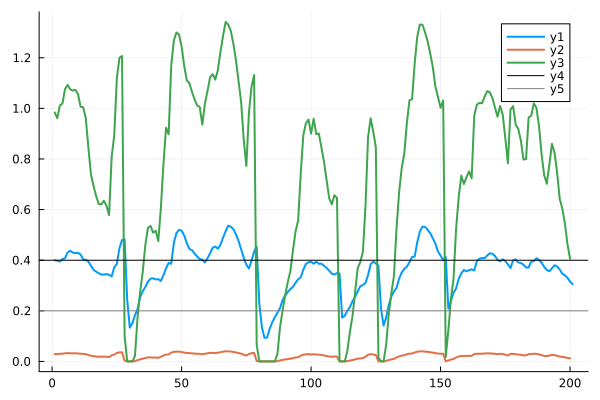

In [3]:
using Plots
X2, X2mc = init_ranom_variables(p;Nquad = 30)
states, m, f, h, y = simulate_trajectory(p,X2,200)
Plots.plot(exp.(states[1,:]), width = 2)
Plots.plot!(h, width = 2)
Plots.plot!(y, width = 2)
Plots.hline!([p.b_target], color = "black")
Plots.hline!([p.b_limit], color = "grey")

In [4]:
mean(y)

0.7482684031061446

## Check state grid

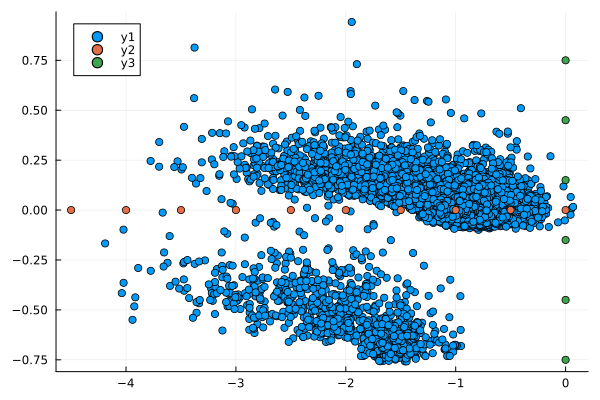

In [5]:
states, m, f, h, y = simulate_trajectory(p,X2,20000)
Plots.scatter(states[1,:], states[2,:])
bmax = 0.0; bmin = -4.5; Nb_grid = 10
b_grid = bmin:((bmax-bmin)/(Nb_grid-1)):bmax
Δbmax = 0.75; Δbmin = -0.75; NΔb_grid = 6
Δb_grid = Δbmin:((Δbmax-Δbmin)/(NΔb_grid-1)):Δbmax
Plots.scatter!(b_grid,[0.0])
Plots.scatter!(zeros(length(Δb_grid)),Δb_grid)

## Define remaining state grids

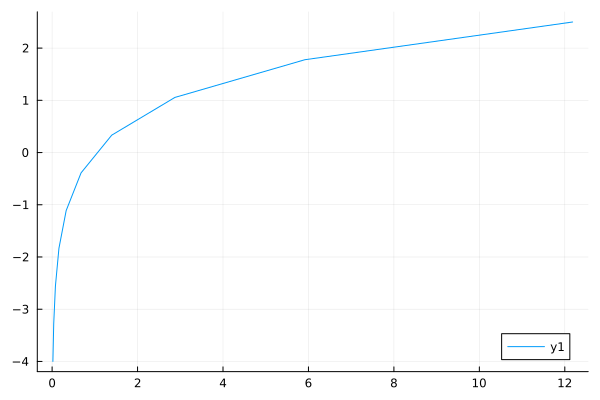

In [6]:
smax = 2.5; smin = -4.0; Ns_grid = 10
s_grid = smin:((smax-smin)/(Ns_grid-1)):smax
Plots.plot(exp.(s_grid),s_grid)

In [7]:
state_grid = [s_grid,b_grid,Δb_grid]
nothing

## Define aciton grid 

In [18]:
κmin = 0.01; κmax = 0.99; Nκ = 10
κ_grid = κmin:((κmax-κmin)/(Nκ-1)):κmax
ηmin = 0.0; ηmax=0.1; Nη = 10
η_grid = ηmin:((ηmax-ηmin)/(Nη-1)):ηmax
action_grid = [κ_grid,η_grid]
κ_grid

0.01:0.10888888888888888:0.99

# Define index and strike

# 

In [19]:
function strike(s,p)
    return 0.5*(p.b_target +p.b_limit) 
end

function index(s,X)
    return exp.(s[1])+X[1]
end 

index (generic function with 1 method)

## Set up model 

In [20]:
δ = 0.95
prob, El = init(action_grid,state_grid,δ,p,X,index,strike)
estimate_time(prob)

The wieght in the random variable do not add to one, there might be an issue with your integration method.

("Estimate (sec)" => 88.84, "One call" => 9.038209915161133e-6, "Number of computations" => 1638240, "actions" => "varaible", "states" => 1216, "random variable samples" => 15, "Estimated iterations" => 60, "Number of threads" => 10)

Progress: 100%|█████████████████████████████████████████| Time: 0:02:43


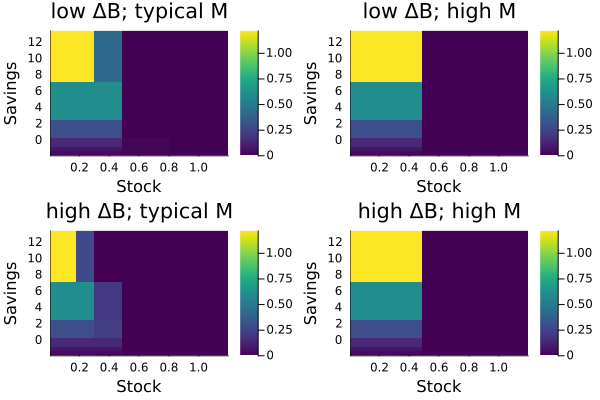

In [22]:
#load_solution(prob,"../results/RA_long/sol.jld2")
solve!(prob)
plot_premiums(prob)

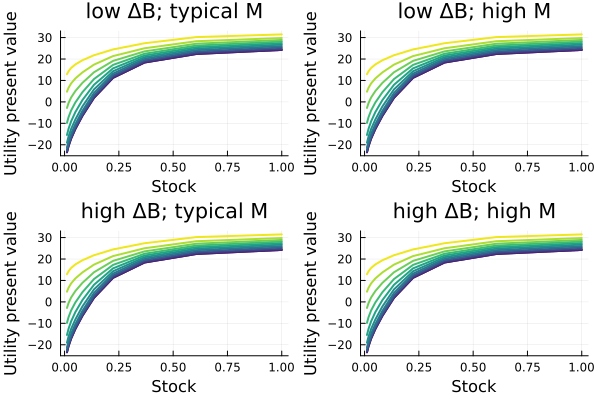

In [26]:
include("../src/plotting.jl")
plot_value_function(prob)

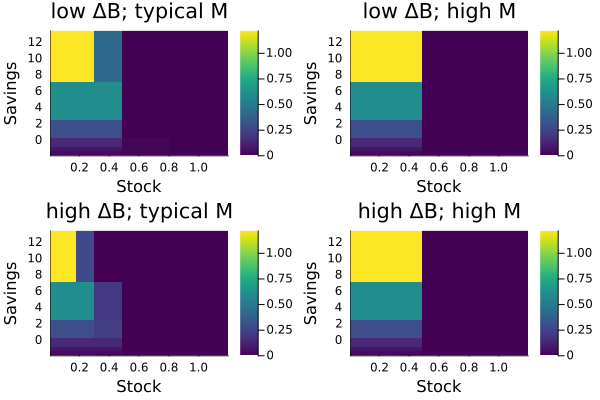

In [27]:
include("../src/plotting.jl")
plot_premiums(prob)

Check premiums and claims: 0.0118? = ? 0.0045


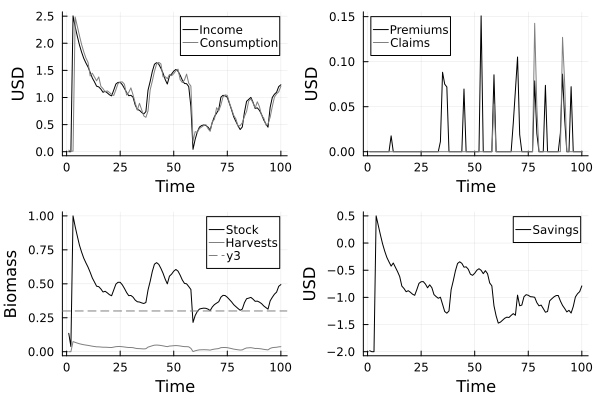

In [30]:
include("../src/plotting.jl")
plt,vals=plot_simulation(prob,El,X2mc,100;with_policy = false)
plt